# FitNova — Squat Training Diagnostics

How the Squat model was trained, and the evidence for **underfitting / overfitting**
decisions. Two stages:
1. **Self-supervised (Motion-Disentangling) pretraining** on the unlabeled set — did it
   learn useful features without representation **collapse**?
2. **Supervised fine-tune** (3 seeds) on the labeled set — train-vs-val curves,
   early-stopping, and the lift over the supervised baseline.

All curves come from the recorded Phase-4 training run (`results.pkl`) — real per-epoch
metrics, not illustrations.

In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt

_d = os.getcwd()
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, ".planning/phases/04-squat-motion-disentangling-ssl/figures/results.pkl")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
R = pickle.load(open(".planning/phases/04-squat-motion-disentangling-ssl/figures/results.pkl", "rb"))
print("results.pkl sections:", list(R.keys()))

def series(metrics, key):
    m = sorted(metrics, key=lambda d: d["epoch"])
    return [d["epoch"] for d in m], [d[key] for d in m]

results.pkl sections: ['final', 'per_seed', 'tta_finding', 'comparison', 'ssl_v1', 'ssl_v2', 'finetune_curves', 'raw']


## 1. SSL pretraining — loss & representation health
Two runs: **v1** (weak augmentations) and **v2** (paper-faithful strong augmentations).
The contrastive loss must go down *without* the representation collapsing.

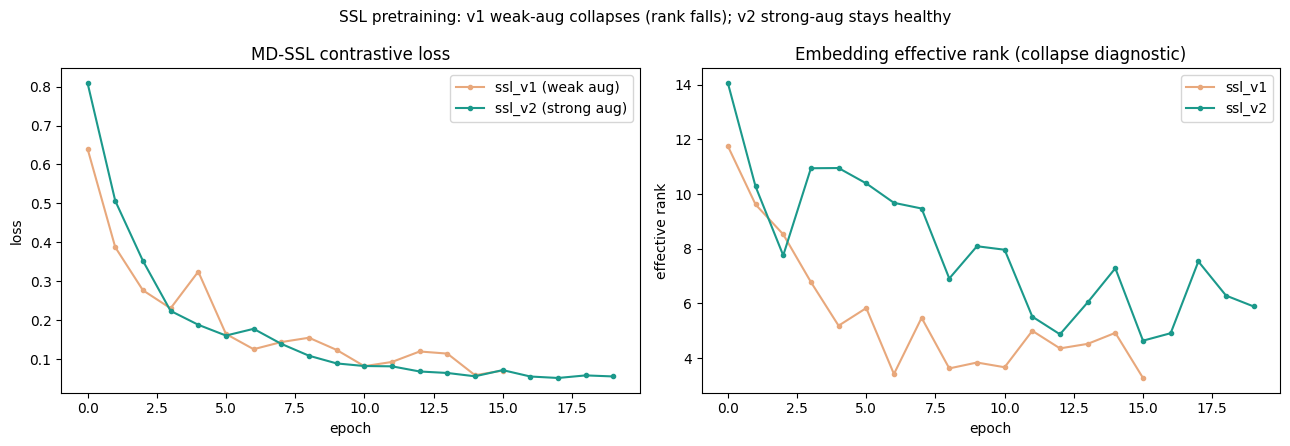

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for tag, color in [("ssl_v1", "#E8A87C"), ("ssl_v2", "#1B998B")]:
    e, loss = series(R[tag]["metrics"], "ssl_loss_mean")
    axs[0].plot(e, loss, "-o", ms=3, color=color, label=f"{tag} ({'weak' if tag=='ssl_v1' else 'strong'} aug)")
axs[0].set_title("MD-SSL contrastive loss"); axs[0].set_xlabel("epoch"); axs[0].set_ylabel("loss"); axs[0].legend()

for tag, color in [("ssl_v1", "#E8A87C"), ("ssl_v2", "#1B998B")]:
    e, er = series(R[tag]["metrics"], "effective_rank")
    axs[1].plot(e, er, "-o", ms=3, color=color, label=tag)
axs[1].set_title("Embedding effective rank (collapse diagnostic)")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("effective rank"); axs[1].legend()
fig.suptitle("SSL pretraining: v1 weak-aug collapses (rank falls); v2 strong-aug stays healthy", fontsize=11)
plt.tight_layout(); plt.show()

**Discovery:** v1 (weak augs) — the loss drops but the **effective rank collapses**
(the embedding degenerates), so it learns little. v2 (paper-faithful strong augs) keeps
the rank healthy. This is why the production backbone is the strong-aug v2 run.

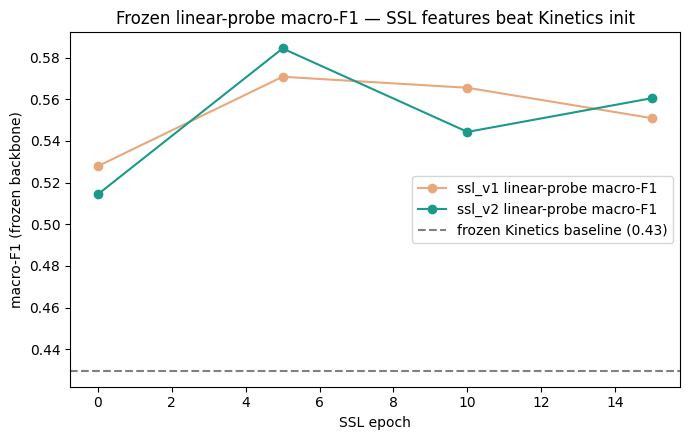

In [3]:
# Linear-probe F1 (frozen backbone) — does SSL learn label-useful features?
fig, ax = plt.subplots(figsize=(7, 4.5))
for tag, color in [("ssl_v1", "#E8A87C"), ("ssl_v2", "#1B998B")]:
    lp = sorted(R[tag]["linear_probe"], key=lambda d: d["epoch"])
    ax.plot([d["epoch"] for d in lp], [d["linear_probe_f1_macro"] for d in lp],
            "-o", color=color, label=f"{tag} linear-probe macro-F1")
ax.axhline(0.4297, color="gray", ls="--", label="frozen Kinetics baseline (0.43)")
ax.set_title("Frozen linear-probe macro-F1 — SSL features beat Kinetics init")
ax.set_xlabel("SSL epoch"); ax.set_ylabel("macro-F1 (frozen backbone)"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Supervised fine-tune — overfitting / underfitting
3 seeds fine-tuned from the shared SSL backbone. **Train-vs-val loss** shows the
over/underfit regime; **val macro-F1** shows convergence + the early-stop epoch.

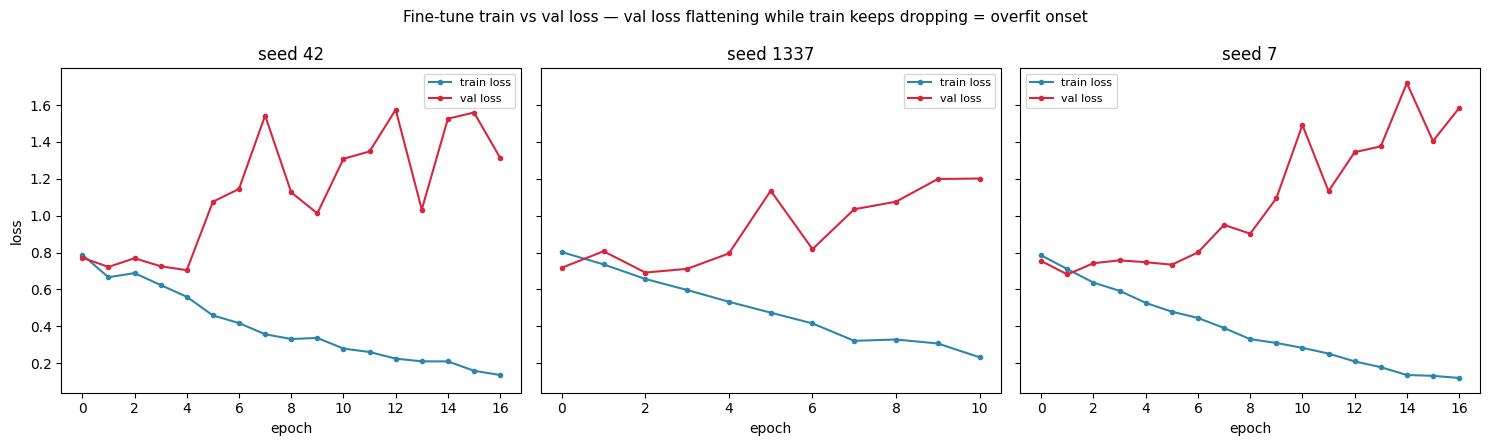

In [4]:
seeds = [42, 1337, 7]
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, sd in zip(axs, seeds):
    c = sorted(R["finetune_curves"][sd], key=lambda d: d["epoch"])
    e = [d["epoch"] for d in c]
    ax.plot(e, [d["train_loss_mean"] for d in c], "-o", ms=3, color="#2E86AB", label="train loss")
    ax.plot(e, [d["val_loss_mean"] for d in c], "-o", ms=3, color="#D7263D", label="val loss")
    ax.set_title(f"seed {sd}"); ax.set_xlabel("epoch"); ax.legend(fontsize=8)
axs[0].set_ylabel("loss")
fig.suptitle("Fine-tune train vs val loss — val loss flattening while train keeps dropping = overfit onset", fontsize=11)
plt.tight_layout(); plt.show()

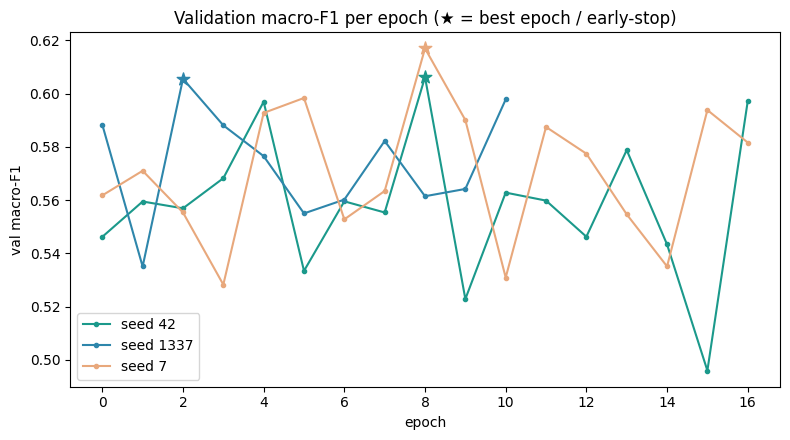

In [5]:
# Val macro-F1 per epoch + best-epoch marker (early-stop point).
fig, ax = plt.subplots(figsize=(8, 4.5))
for sd, color in zip(seeds, ["#1B998B", "#2E86AB", "#E8A87C"]):
    c = sorted(R["finetune_curves"][sd], key=lambda d: d["epoch"])
    e = [d["epoch"] for d in c]; vf = [d["val_macro_f1"] for d in c]
    ax.plot(e, vf, "-o", ms=3, color=color, label=f"seed {sd}")
    bi = int(np.argmax(vf)); ax.scatter([e[bi]], [vf[bi]], color=color, s=90, marker="*", zorder=5)
ax.set_title("Validation macro-F1 per epoch (★ = best epoch / early-stop)")
ax.set_xlabel("epoch"); ax.set_ylabel("val macro-F1"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Baseline -> SSL lift, vs the paper
The supervised Kinetics baseline (Phase 3) vs the MD-SSL model (Phase 4), against
Parmar et al. — identical metric and split.

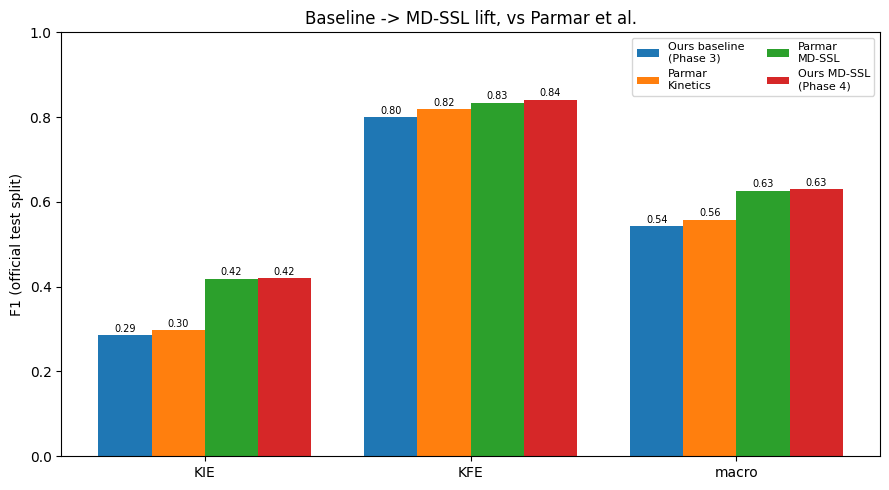

macro: Phase3 baseline 0.543 -> Phase4 MD-SSL 0.630  (paper MD 0.626)


In [6]:
comp = R["comparison"]
order = ["phase3", "paper_kinetics", "paper_md", "phase4_ensemble"]
names = ["Ours baseline\n(Phase 3)", "Parmar\nKinetics", "Parmar\nMD-SSL", "Ours MD-SSL\n(Phase 4)"]
errs = ["KIE", "KFE", "macro"]
x = np.arange(len(errs)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 5))
for i, (k, nm) in enumerate(zip(order, names)):
    vals = [comp[k][e] for e in errs]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=nm)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008, f"{b.get_height():.2f}",
                ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(errs); ax.set_ylim(0, 1)
ax.set_ylabel("F1 (official test split)")
ax.set_title("Baseline -> MD-SSL lift, vs Parmar et al.")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
print("macro: Phase3 baseline %.3f -> Phase4 MD-SSL %.3f  (paper MD %.3f)"
      % (comp["phase3"]["macro"], comp["phase4_ensemble"]["macro"], comp["paper_md"]["macro"]))

## Summary
- **SSL needs strong augmentations:** weak-aug v1 collapses (effective rank falls); the
  strong-aug v2 backbone keeps a healthy embedding and a higher frozen linear-probe F1
  than Kinetics init.
- **Fine-tune is early-stopped** at the best val macro-F1 epoch per seed (train loss keeps
  falling past that → overfit onset on only 1136 labeled clips).
- **The SSL lift is real:** macro-F1 0.543 (supervised baseline) → **0.630** (MD-SSL),
  matching Parmar's MD-SSL (0.626) and beating the Kinetics baseline (0.558).